# 07. Inference, Bands, and Placebo Tests

This notebook implements rigorous inference procedures:
1. Wild cluster bootstrap for robust SEs
2. Joint horizon confidence bands (sup-t)
3. Pre-trend tests
4. Timing placebo tests

**Inputs:**
- `data/03_clean/stacked_events_pos.parquet`
- `data/03_clean/stacked_events_neg.parquet`

**Outputs:**
- Bootstrap confidence intervals
- Pre-trend test results
- Placebo distribution plots

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import statsmodels.api as sm
from statsmodels.regression.linear_model import OLS
import matplotlib.pyplot as plt
from scipy import stats
import json
from datetime import datetime
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Project paths
PROJECT_ROOT = Path(__file__).parent.parent if '__file__' in dir() else Path.cwd().parent
DATA_CLEAN = PROJECT_ROOT / 'data/03_clean'
OUTPUT_FIGURES = PROJECT_ROOT / 'output/figures'
OUTPUT_TABLES = PROJECT_ROOT / 'output/tables'
OUTPUT_LOGS = PROJECT_ROOT / 'output/logs'

for d in [OUTPUT_FIGURES, OUTPUT_TABLES, OUTPUT_LOGS]:
    d.mkdir(parents=True, exist_ok=True)

# Set random seed for reproducibility
np.random.seed(42)

print(f"Project root: {PROJECT_ROOT}")

Project root: /Users/gabrielsaco/Documents/GitHub/economic-freedom


## 1. Load Data

In [2]:
stacked_pos = pd.read_parquet(DATA_CLEAN / 'stacked_events_pos.parquet')
stacked_neg = pd.read_parquet(DATA_CLEAN / 'stacked_events_neg.parquet')

print(f"Positive reforms: {len(stacked_pos)} obs")
print(f"Negative reforms: {len(stacked_neg)} obs")

K = 4  # Pre-periods
L = 6  # Post-periods
event_times = list(range(-K, L+1))

Positive reforms: 45184 obs
Negative reforms: 18408 obs


## 2. Wild Cluster Bootstrap Implementation

In [3]:
def prepare_regression_data(df, outcome_col='y_cumulative', K=2, L=4, omit_period=-1):
    """
    Prepare data for regression, returning design matrices and cluster info.
    """
    df = df.copy()
    df = df.dropna(subset=[outcome_col])
    
    # Create treatment interactions
    for k in range(-K, L+1):
        if k == omit_period:
            continue
        col_name = f'treat_et_{k}' if k < 0 else f'treat_et_p{k}'
        if col_name not in df.columns:
            df[col_name] = ((df['treated'] == 1) & (df['event_time'] == k)).astype(int)
    
    # Cohort-country demeaning
    df['cohort_country'] = df['cohort_id'] + '_' + df['iso3c']
    cc_means = df.groupby('cohort_country')[outcome_col].transform('mean')
    df['y_demeaned'] = df[outcome_col] - cc_means
    
    # Treatment variable names
    treat_cols = []
    for k in range(-K, L+1):
        if k == omit_period:
            continue
        col_name = f'treat_et_{k}' if k < 0 else f'treat_et_p{k}'
        treat_cols.append(col_name)
    
    # Demean treatment interactions
    for col in treat_cols:
        cc_mean = df.groupby('cohort_country')[col].transform('mean')
        df[col + '_dm'] = df[col] - cc_mean
    
    treat_cols_dm = [c + '_dm' for c in treat_cols]
    
    # Design matrix (just treatment interactions for simplicity)
    X = df[treat_cols_dm].values
    y = df['y_demeaned'].values
    clusters = df['iso3c'].values
    
    return X, y, clusters, treat_cols_dm, df


def wild_cluster_bootstrap(X, y, clusters, n_bootstrap=999, seed=42):
    """
    Wild cluster bootstrap for clustered standard errors.
    
    Uses Rademacher weights (+1, -1 with equal probability).
    
    Parameters
    ----------
    X : ndarray
        Design matrix (n x p)
    y : ndarray
        Outcome vector (n,)
    clusters : ndarray
        Cluster identifiers (n,)
    n_bootstrap : int
        Number of bootstrap replications
    seed : int
        Random seed
        
    Returns
    -------
    dict with point estimates, bootstrap distribution, CIs
    """
    np.random.seed(seed)
    
    # Original estimation
    X_const = np.column_stack([np.ones(len(y)), X])
    model = OLS(y, X_const)
    original_results = model.fit()
    original_coefs = original_results.params[1:]  # Exclude constant
    original_resids = original_results.resid
    
    # Get unique clusters
    unique_clusters = np.unique(clusters)
    n_clusters = len(unique_clusters)
    
    # Bootstrap
    boot_coefs = np.zeros((n_bootstrap, len(original_coefs)))
    
    for b in range(n_bootstrap):
        # Rademacher weights at cluster level
        weights = np.random.choice([-1, 1], size=n_clusters)
        cluster_weights = dict(zip(unique_clusters, weights))
        
        # Apply weights to residuals
        obs_weights = np.array([cluster_weights[c] for c in clusters])
        y_star = original_results.fittedvalues + obs_weights * original_resids
        
        # Re-estimate
        model_star = OLS(y_star, X_const)
        results_star = model_star.fit()
        boot_coefs[b] = results_star.params[1:]
    
    # Confidence intervals (percentile method)
    ci_lower = np.percentile(boot_coefs, 2.5, axis=0)
    ci_upper = np.percentile(boot_coefs, 97.5, axis=0)
    
    # Bootstrap standard errors
    boot_se = np.std(boot_coefs, axis=0)
    
    return {
        'point_estimates': original_coefs,
        'boot_distribution': boot_coefs,
        'ci_lower': ci_lower,
        'ci_upper': ci_upper,
        'boot_se': boot_se,
        'n_bootstrap': n_bootstrap,
        'n_clusters': n_clusters,
    }

## 3. Run Wild Cluster Bootstrap

In [4]:
print("Running wild cluster bootstrap for POSITIVE reforms...")
X_pos, y_pos, clusters_pos, treat_cols_pos, df_pos = prepare_regression_data(stacked_pos, K=K, L=L)
boot_pos = wild_cluster_bootstrap(X_pos, y_pos, clusters_pos, n_bootstrap=999)

print(f"  Observations: {len(y_pos)}")
print(f"  Clusters: {boot_pos['n_clusters']}")
print(f"  Bootstrap replications: {boot_pos['n_bootstrap']}")

Running wild cluster bootstrap for POSITIVE reforms...
  Observations: 40593
  Clusters: 163
  Bootstrap replications: 999


In [5]:
print("\nRunning wild cluster bootstrap for NEGATIVE reforms...")
X_neg, y_neg, clusters_neg, treat_cols_neg, df_neg = prepare_regression_data(stacked_neg, K=K, L=L)
boot_neg = wild_cluster_bootstrap(X_neg, y_neg, clusters_neg, n_bootstrap=999)

print(f"  Observations: {len(y_neg)}")
print(f"  Clusters: {boot_neg['n_clusters']}")


Running wild cluster bootstrap for NEGATIVE reforms...
  Observations: 15310
  Clusters: 164


## 4. Joint Horizon Bands (Sup-t Bootstrap)

In [6]:
def compute_sup_t_bands(boot_distribution, point_estimates, alpha=0.05):
    """
    Compute joint horizon confidence bands using sup-t bootstrap.
    
    The sup-t method finds a critical value c such that:
    P(max_k |β_k - β̂_k| / se_k <= c) = 1 - α
    
    This ensures simultaneous coverage across all horizons.
    """
    n_boot, n_coefs = boot_distribution.shape
    
    # Compute t-statistics for each bootstrap
    boot_se = np.std(boot_distribution, axis=0)
    
    # Avoid division by zero
    boot_se = np.maximum(boot_se, 1e-10)
    
    # Center bootstrap distribution
    centered = boot_distribution - point_estimates
    t_stats = np.abs(centered) / boot_se
    
    # Maximum t-stat across horizons for each bootstrap
    max_t = np.max(t_stats, axis=1)
    
    # Critical value at (1-α) quantile
    c_alpha = np.percentile(max_t, 100 * (1 - alpha))
    
    # Joint bands
    joint_lower = point_estimates - c_alpha * boot_se
    joint_upper = point_estimates + c_alpha * boot_se
    
    return {
        'c_alpha': c_alpha,
        'joint_lower': joint_lower,
        'joint_upper': joint_upper,
        'alpha': alpha,
    }

# Compute sup-t bands
supt_pos = compute_sup_t_bands(boot_pos['boot_distribution'], boot_pos['point_estimates'])
supt_neg = compute_sup_t_bands(boot_neg['boot_distribution'], boot_neg['point_estimates'])

print(f"Sup-t critical value (95%): Positive={supt_pos['c_alpha']:.3f}, Negative={supt_neg['c_alpha']:.3f}")

Sup-t critical value (95%): Positive=2.310, Negative=2.322


## 5. Plot IRFs with Bootstrap and Sup-t Bands

✓ Saved figure to /Users/gabrielsaco/Documents/GitHub/economic-freedom/output/figures/fig_irf_pos_bootstrap.pdf


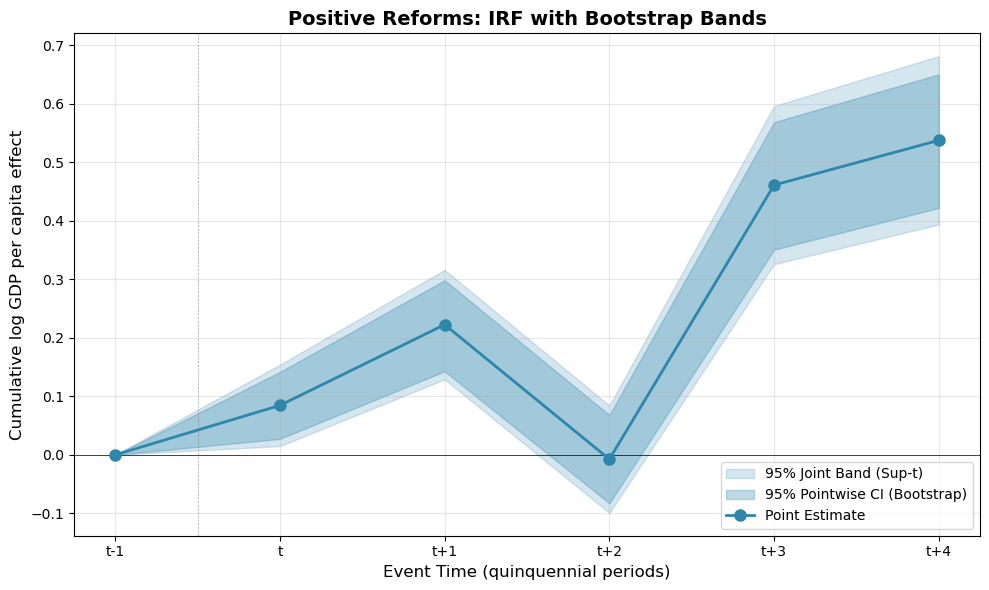

✓ Saved figure to /Users/gabrielsaco/Documents/GitHub/economic-freedom/output/figures/fig_irf_neg_bootstrap.pdf


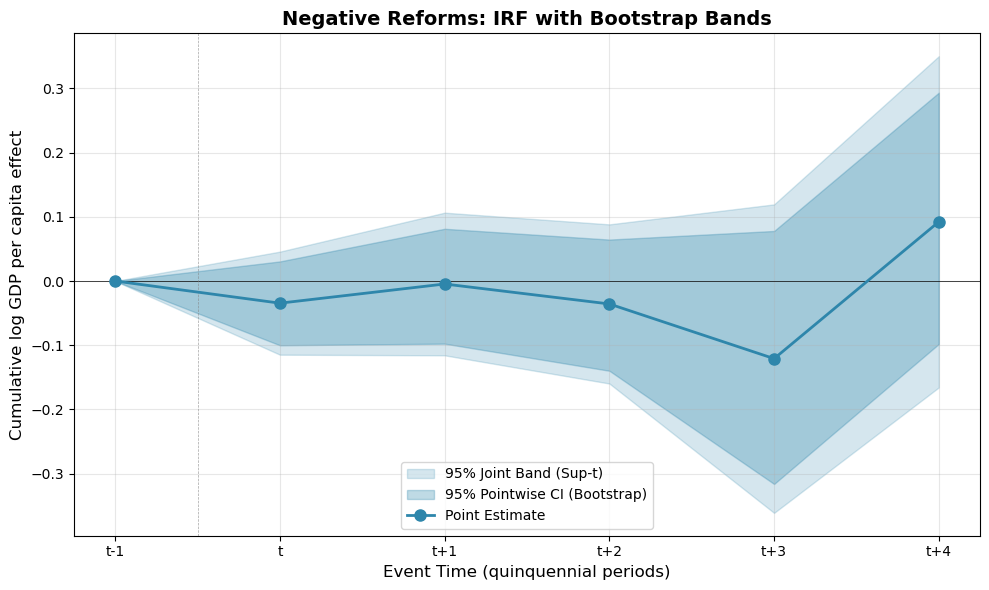

In [7]:
def plot_irf_with_bands(boot_results, supt_results, treat_cols, K=2, L=4, 
                         title='', save_path=None):
    """
    Plot IRF with pointwise and joint confidence bands.
    """
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Map column names to event times
    event_times = []
    for col in treat_cols:
        if 'et_-' in col:
            k = -int(col.split('_')[2].replace('dm', ''))
        elif 'et_p' in col:
            k = int(col.split('_')[2].replace('p', '').replace('dm', ''))
        else:
            continue
        event_times.append(k)
    
    # Add omitted period (t=-1)
    all_times = sorted(set(event_times) | {-1})
    
    # Build coefficient vectors with 0 at omitted period
    coefs = []
    pw_lower = []
    pw_upper = []
    joint_lower = []
    joint_upper = []
    
    for k in all_times:
        if k == -1:  # Omitted period
            coefs.append(0)
            pw_lower.append(0)
            pw_upper.append(0)
            joint_lower.append(0)
            joint_upper.append(0)
        else:
            idx = event_times.index(k)
            coefs.append(boot_results['point_estimates'][idx])
            pw_lower.append(boot_results['ci_lower'][idx])
            pw_upper.append(boot_results['ci_upper'][idx])
            joint_lower.append(supt_results['joint_lower'][idx])
            joint_upper.append(supt_results['joint_upper'][idx])
    
    # Reference lines
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    ax.axvline(x=-0.5, color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
    
    # Joint bands (wider, lighter)
    ax.fill_between(all_times, joint_lower, joint_upper, 
                    alpha=0.2, color='#2E86AB', label='95% Joint Band (Sup-t)')
    
    # Pointwise bands
    ax.fill_between(all_times, pw_lower, pw_upper,
                    alpha=0.3, color='#2E86AB', label='95% Pointwise CI (Bootstrap)')
    
    # Point estimates
    ax.plot(all_times, coefs, 'o-', color='#2E86AB', 
            markersize=8, linewidth=2, label='Point Estimate')
    
    ax.set_xlabel('Event Time (quinquennial periods)', fontsize=12)
    ax.set_ylabel('Cumulative log GDP per capita effect', fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xticks(all_times)
    ax.set_xticklabels([f't{k:+d}' if k != 0 else 't' for k in all_times])
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✓ Saved figure to {save_path}")
    
    plt.show()
    return fig

# Plot positive reforms with bands
fig_pos = plot_irf_with_bands(
    boot_pos, supt_pos, treat_cols_pos, K=K, L=L,
    title='Positive Reforms: IRF with Bootstrap Bands',
    save_path=OUTPUT_FIGURES / 'fig_irf_pos_bootstrap.pdf'
)

# Plot negative reforms with bands
fig_neg = plot_irf_with_bands(
    boot_neg, supt_neg, treat_cols_neg, K=K, L=L,
    title='Negative Reforms: IRF with Bootstrap Bands',
    save_path=OUTPUT_FIGURES / 'fig_irf_neg_bootstrap.pdf'
)

## 6. Pre-trend Tests

In [8]:
def test_pretrends(boot_results, treat_cols, K=2):
    """
    Joint test of pre-trend coefficients = 0.
    
    Uses bootstrap distribution to compute:
    1. Joint F-test (Wald)
    2. Bootstrap p-value for joint null
    """
    # Identify pre-period coefficients
    pre_indices = []
    for i, col in enumerate(treat_cols):
        if 'et_-' in col:
            pre_indices.append(i)
    
    if len(pre_indices) == 0:
        return {'pvalue': np.nan, 'joint_stat': np.nan}
    
    # Pre-period coefficients
    pre_coefs = boot_results['point_estimates'][pre_indices]
    pre_boot = boot_results['boot_distribution'][:, pre_indices]
    
    # Wald statistic (sum of squared t-stats)
    pre_se = boot_results['boot_se'][pre_indices]
    pre_se = np.maximum(pre_se, 1e-10)
    
    wald_stat = np.sum((pre_coefs / pre_se) ** 2)
    
    # Bootstrap p-value
    boot_wald = np.sum((pre_boot / pre_se) ** 2, axis=1)
    pvalue = np.mean(boot_wald >= wald_stat)
    
    # Individual tests
    individual_pvals = []
    for i, idx in enumerate(pre_indices):
        t_stat = abs(pre_coefs[i] / pre_se[i])
        boot_t = np.abs(boot_results['boot_distribution'][:, idx]) / pre_se[i]
        pval = np.mean(boot_t >= t_stat)
        individual_pvals.append(pval)
    
    return {
        'joint_stat': wald_stat,
        'joint_pvalue': pvalue,
        'individual_coefs': pre_coefs,
        'individual_ses': pre_se,
        'individual_pvals': individual_pvals,
        'pre_indices': pre_indices,
    }

# Test pre-trends
pretrend_pos = test_pretrends(boot_pos, treat_cols_pos, K=K)
pretrend_neg = test_pretrends(boot_neg, treat_cols_neg, K=K)

print("\nPre-trend Test Results")
print("="*60)
print(f"{'Test':<30} {'Positive':>15} {'Negative':>15}")
print("-"*60)
print(f"{'Joint Wald statistic':<30} {pretrend_pos['joint_stat']:>15.3f} {pretrend_neg['joint_stat']:>15.3f}")
print(f"{'Joint p-value':<30} {pretrend_pos['joint_pvalue']:>15.3f} {pretrend_neg['joint_pvalue']:>15.3f}")
print("-"*60)

print("\nIndividual pre-period tests (Positive):")
for i, idx in enumerate(pretrend_pos['pre_indices']):
    col = treat_cols_pos[idx]
    print(f"  {col}: coef={pretrend_pos['individual_coefs'][i]:.4f}, p={pretrend_pos['individual_pvals'][i]:.3f}")

print("\nIndividual pre-period tests (Negative):")
for i, idx in enumerate(pretrend_neg['pre_indices']):
    col = treat_cols_neg[idx]
    print(f"  {col}: coef={pretrend_neg['individual_coefs'][i]:.4f}, p={pretrend_neg['individual_pvals'][i]:.3f}")


Pre-trend Test Results
Test                                  Positive        Negative
------------------------------------------------------------
Joint Wald statistic                     0.035           0.447
Joint p-value                            0.853           0.603
------------------------------------------------------------

Individual pre-period tests (Positive):
  treat_et_-2_dm: coef=-0.0075, p=0.853

Individual pre-period tests (Negative):
  treat_et_-2_dm: coef=-0.0357, p=0.603


## 7. Timing Placebo Test

In [9]:
def timing_placebo_test(df, true_boot_results, treat_cols, n_placebos=200, K=2, L=4, seed=42):
    """
    Randomize timing of events within countries and compare to true effect.
    
    Preserves:
    - Number of events per country
    - Overall event count
    
    Randomizes:
    - Timing of events
    """
    np.random.seed(seed)
    
    # Get true cumulative effect (post-treatment sum)
    post_indices = [i for i, col in enumerate(treat_cols) if 'et_p' in col]
    true_cumulative = np.sum(true_boot_results['point_estimates'][post_indices])
    
    placebo_cumulatives = []
    
    for p in tqdm(range(n_placebos), desc="Placebo iterations"):
        df_placebo = df.copy()
        
        # For each cohort, randomize the event year
        for cohort_id in df_placebo['cohort_id'].unique():
            cohort_mask = df_placebo['cohort_id'] == cohort_id
            cohort_data = df_placebo[cohort_mask]
            
            # Get treated unit and its years
            treated_data = cohort_data[cohort_data['treated'] == 1]
            if len(treated_data) == 0:
                continue
            
            available_years = treated_data['year'].unique()
            if len(available_years) == 0:
                continue
            
            # Randomly assign a new event year
            new_event_year = np.random.choice(available_years)
            
            # Recompute event_time
            df_placebo.loc[cohort_mask, 'event_time_placebo'] = \
                (df_placebo.loc[cohort_mask, 'year'] - new_event_year) // 5
        
        # Only proceed if we have the placebo event_time
        if 'event_time_placebo' not in df_placebo.columns:
            continue
        
        # Recreate treatment interactions
        for k in range(-K, L+1):
            if k == -1:
                continue
            col_name = f'treat_et_placebo_{k}'
            df_placebo[col_name] = ((df_placebo['treated'] == 1) & 
                                    (df_placebo['event_time_placebo'] == k)).astype(int)
        
        # Estimate (simplified - just get coefficients)
        outcome_col = 'y_cumulative'
        df_valid = df_placebo.dropna(subset=[outcome_col])
        
        if len(df_valid) < 100:
            continue
        
        # Demean and estimate
        df_valid['cohort_country'] = df_valid['cohort_id'] + '_' + df_valid['iso3c']
        cc_means = df_valid.groupby('cohort_country')[outcome_col].transform('mean')
        y = df_valid[outcome_col] - cc_means
        
        placebo_treat_cols = [f'treat_et_placebo_{k}' for k in range(-K, L+1) if k != -1]
        existing_cols = [c for c in placebo_treat_cols if c in df_valid.columns]
        
        if len(existing_cols) == 0:
            continue
        
        for col in existing_cols:
            cc_mean = df_valid.groupby('cohort_country')[col].transform('mean')
            df_valid[col + '_dm'] = df_valid[col] - cc_mean
        
        X = df_valid[[c + '_dm' for c in existing_cols]].values
        X_const = np.column_stack([np.ones(len(y)), X])
        
        try:
            model = OLS(y, X_const)
            results = model.fit()
            
            # Get post-treatment cumulative
            post_placebo_indices = [i for i, col in enumerate(existing_cols) if 'placebo_0' in col or 
                                    'placebo_1' in col or 'placebo_2' in col or 
                                    'placebo_3' in col or 'placebo_4' in col]
            if len(post_placebo_indices) > 0:
                placebo_cumulative = np.sum(results.params[1:][post_placebo_indices])
                placebo_cumulatives.append(placebo_cumulative)
        except:
            continue
    
    if len(placebo_cumulatives) == 0:
        return {'pvalue': np.nan, 'true_effect': true_cumulative}
    
    placebo_cumulatives = np.array(placebo_cumulatives)
    
    # Two-sided p-value
    pvalue = np.mean(np.abs(placebo_cumulatives) >= np.abs(true_cumulative))
    
    return {
        'true_effect': true_cumulative,
        'placebo_distribution': placebo_cumulatives,
        'pvalue': pvalue,
        'n_placebos': len(placebo_cumulatives),
    }

# Run placebo test (reduced iterations for speed)
print("\nRunning timing placebo test for POSITIVE reforms...")
placebo_pos = timing_placebo_test(df_pos, boot_pos, treat_cols_pos, n_placebos=100)

print(f"  True cumulative effect: {placebo_pos['true_effect']:.4f}")
print(f"  Placebo p-value: {placebo_pos['pvalue']:.3f}")

print("\nRunning timing placebo test for NEGATIVE reforms...")
placebo_neg = timing_placebo_test(df_neg, boot_neg, treat_cols_neg, n_placebos=100)

print(f"  True cumulative effect: {placebo_neg['true_effect']:.4f}")
print(f"  Placebo p-value: {placebo_neg['pvalue']:.3f}")


Running timing placebo test for POSITIVE reforms...


Placebo iterations: 100%|██████████| 100/100 [00:13<00:00,  7.62it/s]


  True cumulative effect: 1.6565
  Placebo p-value: 0.040

Running timing placebo test for NEGATIVE reforms...


Placebo iterations: 100%|██████████| 100/100 [00:04<00:00, 24.71it/s]

  True cumulative effect: -0.1197
  Placebo p-value: 0.600


## 8. Placebo Distribution Plot

✓ Saved figure to /Users/gabrielsaco/Documents/GitHub/economic-freedom/output/figures/fig_placebo_pos.pdf


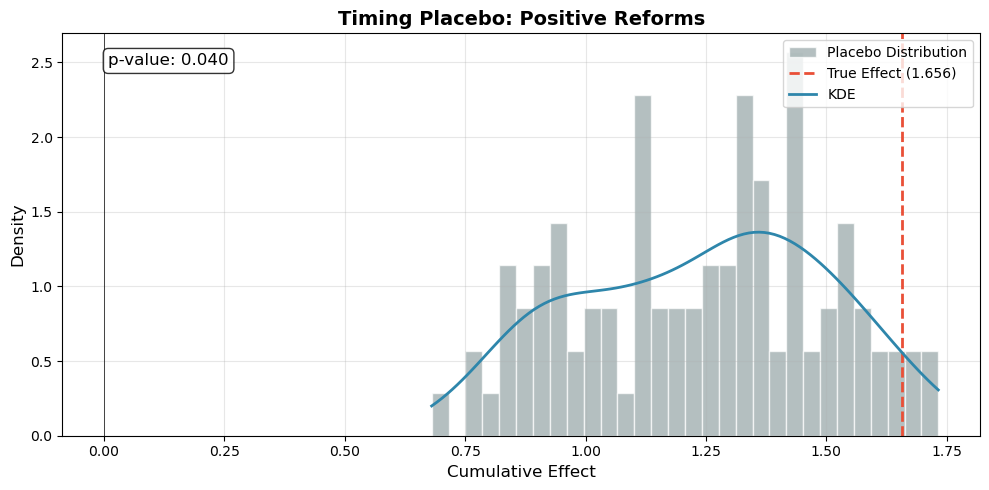

✓ Saved figure to /Users/gabrielsaco/Documents/GitHub/economic-freedom/output/figures/fig_placebo_neg.pdf


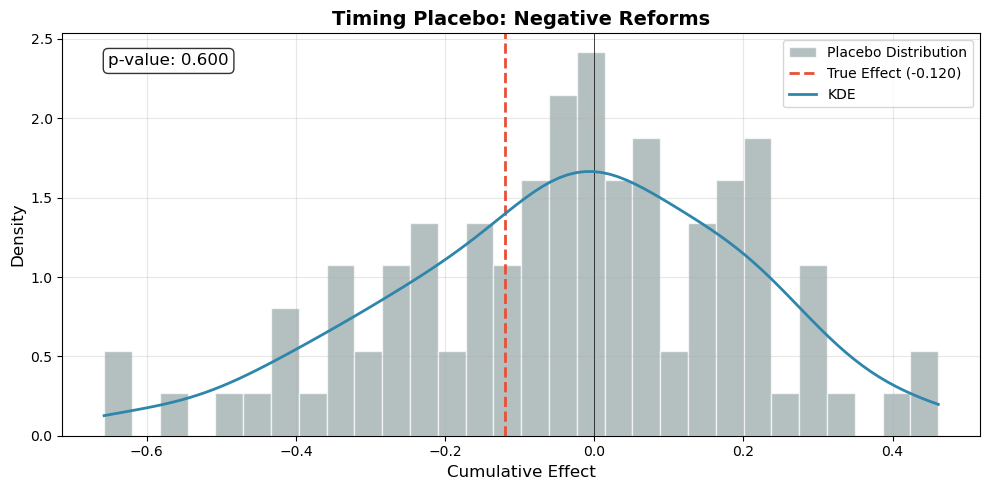

In [10]:
def plot_placebo_distribution(placebo_results, title, save_path=None):
    """
    Plot placebo distribution with true effect marked.
    """
    if 'placebo_distribution' not in placebo_results or len(placebo_results['placebo_distribution']) == 0:
        print(f"No placebo distribution available for {title}")
        return
    
    fig, ax = plt.subplots(figsize=(10, 5))
    
    placebo = placebo_results['placebo_distribution']
    true_effect = placebo_results['true_effect']
    
    ax.hist(placebo, bins=30, density=True, alpha=0.7, color='#95A5A6',
            edgecolor='white', label='Placebo Distribution')
    
    ax.axvline(x=true_effect, color='#E94F37', linewidth=2, linestyle='--',
               label=f'True Effect ({true_effect:.3f})')
    
    ax.axvline(x=0, color='black', linewidth=0.5)
    
    # Add kernel density estimate
    from scipy.stats import gaussian_kde
    kde = gaussian_kde(placebo)
    x_range = np.linspace(min(placebo), max(placebo), 100)
    ax.plot(x_range, kde(x_range), color='#2E86AB', linewidth=2, label='KDE')
    
    ax.set_xlabel('Cumulative Effect', fontsize=12)
    ax.set_ylabel('Density', fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)
    
    # Add p-value annotation
    ax.annotate(f'p-value: {placebo_results["pvalue"]:.3f}',
                xy=(0.05, 0.95), xycoords='axes fraction',
                fontsize=12, ha='left', va='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✓ Saved figure to {save_path}")
    
    plt.show()
    return fig

if 'placebo_distribution' in placebo_pos and len(placebo_pos.get('placebo_distribution', [])) > 0:
    plot_placebo_distribution(
        placebo_pos, 
        'Timing Placebo: Positive Reforms',
        save_path=OUTPUT_FIGURES / 'fig_placebo_pos.pdf'
    )

if 'placebo_distribution' in placebo_neg and len(placebo_neg.get('placebo_distribution', [])) > 0:
    plot_placebo_distribution(
        placebo_neg,
        'Timing Placebo: Negative Reforms', 
        save_path=OUTPUT_FIGURES / 'fig_placebo_neg.pdf'
    )

## 9. Save Results

In [11]:
# Compile all inference results
inference_results = {
    'timestamp': datetime.now().isoformat(),
    'bootstrap': {
        'n_replications': boot_pos['n_bootstrap'],
        'method': 'wild_cluster_bootstrap',
        'weight_type': 'rademacher',
    },
    'positive_reforms': {
        'n_clusters': boot_pos['n_clusters'],
        'supt_critical_value': supt_pos['c_alpha'],
        'pretrend_joint_pvalue': pretrend_pos['joint_pvalue'],
        'placebo_pvalue': placebo_pos.get('pvalue', np.nan),
    },
    'negative_reforms': {
        'n_clusters': boot_neg['n_clusters'],
        'supt_critical_value': supt_neg['c_alpha'],
        'pretrend_joint_pvalue': pretrend_neg['joint_pvalue'],
        'placebo_pvalue': placebo_neg.get('pvalue', np.nan),
    },
}

# Save
results_path = OUTPUT_LOGS / 'inference_results.json'
with open(results_path, 'w') as f:
    json.dump(inference_results, f, indent=2, default=lambda x: float(x) if isinstance(x, np.floating) else str(x))

print(f"✓ Saved inference results to {results_path}")

# Create pre-trend test table
pretrend_table = pd.DataFrame({
    'Reform Type': ['Positive', 'Negative'],
    'Joint Wald Stat': [pretrend_pos['joint_stat'], pretrend_neg['joint_stat']],
    'Joint p-value': [pretrend_pos['joint_pvalue'], pretrend_neg['joint_pvalue']],
    'Placebo p-value': [placebo_pos.get('pvalue', np.nan), placebo_neg.get('pvalue', np.nan)],
})

# Save as LaTeX
latex_pretrend = pretrend_table.to_latex(index=False, float_format='%.3f')
table_path = OUTPUT_TABLES / 'tab_pretrends_placebos.tex'
with open(table_path, 'w') as f:
    f.write(latex_pretrend)
print(f"✓ Saved pre-trend table to {table_path}")

✓ Saved inference results to /Users/gabrielsaco/Documents/GitHub/economic-freedom/output/logs/inference_results.json
✓ Saved pre-trend table to /Users/gabrielsaco/Documents/GitHub/economic-freedom/output/tables/tab_pretrends_placebos.tex


## 10. Summary

In [12]:
print("\n" + "="*60)
print("07_INFERENCE_BANDS_PLACEBOS COMPLETE")
print("="*60)
print(f"Wild cluster bootstrap: {boot_pos['n_bootstrap']} replications")
print(f"\nPre-trend tests (Joint p-value):")
print(f"  Positive reforms: {pretrend_pos['joint_pvalue']:.3f}")
print(f"  Negative reforms: {pretrend_neg['joint_pvalue']:.3f}")
print(f"\nTiming placebo tests:")
print(f"  Positive reforms: p={placebo_pos.get('pvalue', np.nan):.3f}")
print(f"  Negative reforms: p={placebo_neg.get('pvalue', np.nan):.3f}")
print(f"\nOutputs:")
print(f"  - {OUTPUT_FIGURES / 'fig_irf_pos_bootstrap.pdf'}")
print(f"  - {OUTPUT_FIGURES / 'fig_irf_neg_bootstrap.pdf'}")
print(f"  - {OUTPUT_TABLES / 'tab_pretrends_placebos.tex'}")
print("="*60)


07_INFERENCE_BANDS_PLACEBOS COMPLETE
Wild cluster bootstrap: 999 replications

Pre-trend tests (Joint p-value):
  Positive reforms: 0.853
  Negative reforms: 0.603

Timing placebo tests:
  Positive reforms: p=0.040
  Negative reforms: p=0.600

Outputs:
  - /Users/gabrielsaco/Documents/GitHub/economic-freedom/output/figures/fig_irf_pos_bootstrap.pdf
  - /Users/gabrielsaco/Documents/GitHub/economic-freedom/output/figures/fig_irf_neg_bootstrap.pdf
  - /Users/gabrielsaco/Documents/GitHub/economic-freedom/output/tables/tab_pretrends_placebos.tex
